# Trabalho Final – Fundamentos de Ciência de Dados

## Análise Exploratória das Ocorrências Criminais no Rio Grande do Sul em 2025

### **Nome: Caio Cristiano Antunes Assmann**

### Fonte dos Dados
Secretaria de Segurança Pública do Rio Grande do Sul (SSP-RS) - 2025

### Objetivo
Analisar padrões de criminalidade no Rio Grande do Sul durante o ano de 2025 utilizando técnicas de análise exploratória de dados.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [2]:
import os

# Tenta rodar no Google Colab; se não estiver no Colab, usa arquivo local
try:
    from google.colab import drive
    drive.mount('/content/drive')
    caminho_arquivo = '/content/drive/MyDrive/COLAB DATASET/SPJ_OCORRENCIAS_2025.xlsx'
except ImportError:
    # Fora do Colab: coloque o arquivo na mesma pasta do notebook
    caminho_arquivo = 'SPJ_OCORRENCIAS_2025.xlsx'

df = pd.read_excel(caminho_arquivo)

Mounted at /content/drive


## **Exploração Inicial dos Dados**

In [3]:
df.head()

,Sequência,Data Fato,Hora Fato,Grupo Fato,Tipo Enquadramento,Tipo Fato,Municipio Fato,Local Fato,Bairro,Quantidade Vítimas,Idade Vítima,Sexo Vítima,Cor Vítima
0,1,2025-01-01,00:01:00,CONTRAVENCOES,PERTURBACAO DO TRABALHO OU DO SOSSEGO ALHEIOS,Consumado,CAXIAS DO SUL,OUTROS,Pedancino,1.0,75.0,Masculino,Branca
1,2,2025-01-01,00:01:00,CRIMES,FURTO QUALIFICADO,Consumado,PIRATINI,OUTROS,NaN,1.0,84.0,Masculino,Branca
2,3,2025-01-01,00:01:00,CRIMES,FURTO EM VEICULO,Consumado,TORRES,VIA PUBLICA,PRAIA DA CAL,1.0,21.0,Masculino,Branca
3,4,2025-01-01,00:01:00,CRIMES,AMEACA,Consumado,TRAMANDAI,OUTROS,Tramandaí,1.0,15.0,Masculino,Branca
4,5,2025-01-01,00:01:00,CRIMES,APROPRIACAO INDEBITA DE BEM DE IDOSO,Consumado,ERECHIM,RESIDENCIA,LINHO,1.0,73.0,Feminino,Branca


In [4]:
df.shape

(763795, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 763795 entries, 0 to 763794
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Sequência           763795 non-null  int64         
 1   Data Fato           763795 non-null  datetime64[ns]
 2   Hora Fato           763795 non-null  object        
 3   Grupo Fato          763795 non-null  object        
 4   Tipo Enquadramento  763795 non-null  object        
 5   Tipo Fato           763795 non-null  object        
 6   Municipio Fato      763795 non-null  object        
 7   Local Fato          763795 non-null  object        
 8   Bairro              616315 non-null  object        
 9   Quantidade Vítimas  763790 non-null  float64       
 10  Idade Vítima        619363 non-null  float64       
 11  Sexo Vítima         618493 non-null  object        
 12  Cor Vítima          619364 non-null  object        
dtypes: datetime64[ns](1), float64

###Interpretação

A base possui aproximadamente 763 mil registros de ocorrências criminais e 13 colunas contendo informações sobre o crime, vítima e local da ocorrência.

### Verificando valores nulos

In [6]:
df.isnull().sum()

,0
Sequência,0
Data Fato,0
Hora Fato,0
Grupo Fato,0
Tipo Enquadramento,0
Tipo Fato,0
Municipio Fato,0
Local Fato,0
Bairro,147480
Quantidade Vítimas,5


### Criando cópia para tratamento dedados, sem alterar a tabela original.

In [7]:
df_tratado = df.copy()

### Interpretação

Observou-se a presença de dados ausentes principalmente nas colunas relacionadas ao perfil das vítimas, como idade, sexo e cor da vítima.

## **Tratamento dos Dados**

Verificando as variações de nomes dos bairros de Porto Alegre.

In [8]:
CRIMES= sorted(
    df_tratado['Tipo Enquadramento']
    .dropna().astype(str).unique()
)

for crime in CRIMES:
    print(crime)

ABANDONO DE FUNCAO
ABANDONO DE IDOSO
ABANDONO DE INCAPAZ
ABANDONO DE PESSOA COM DEFICIENCIA
ABANDONO INTELECTUAL
ABANDONO MATERIAL
ABORTO
ABUSO DE INCAPAZ
ADULTERACAO DE SINAL IDENTIFICADOR DE VEICULO AUTOMOTOR
ADVOCACIA ADMINISTRATIVA
AFIRMACAO ENGANOSA SOBRE PRODUTO
ALTERACAO LIMITES DIVISORIOS
AMEACA
AMEACA A ESTABELECIMENTO DE ENSINO
APOLOGIA AO NAZISMO
APOLOGIA DE CRIME OU CRIMINOSO
APROPRIACAO COISA HAVIDA POR ERRO CASO FORTUITO OU FORCA DA NATUREZA
APROPRIACAO DE BENS DE PESSOA COM DEFICIENCIA
APROPRIACAO DE COISA ACHADA
APROPRIACAO INDEBITA
APROPRIACAO INDEBITA DE BEM DE IDOSO
ARREMESSO DE PROJETIL  ART 264 CP
ASSEDIO SEXUAL
ASSOCIACAO CRIMINOSA ART 288 DO CP
ATENTADO CONTRA SEGURANCA SERV UTILIDADE PUBLICA
ATIVIDADE CLANDESTINA DE TELECOMUNICACOES
ATIVIDADE(S) COM RISCOS A SEGURANCA
ATO OBSCENO
CALUNIA
CASA DE PROSTITUICAO
CHARLATANISMO
COACAO NO CURSO DO PROCESSO
COMERCIO ILEGAL DE ARMA DE FOGO
COMUNICACAO FALSA DE CRIME OU CONTRAVENCAO
CONCORRENCIA DESLEAL
CONCUSSAO
CONDICIO

In [9]:
bairros_poa = sorted(
    df_tratado[
        df_tratado['Municipio Fato'] == 'PORTO ALEGRE'
    ]['Bairro']
    .dropna().astype(str).unique()
)

for bairro in bairros_poa:
    print(bairro)

'Jardim Europa
-
.
0
102
1170
25 And
?
A
ABERTA DOS MORROS
ABERTA DOS MORROS-
ABERTA MORROS
AC 3 HIPICA
AGRONOMIA
AGRONOMIA (PORTO ALE
ALVORADA
AMERICANA ALVORADA
ANCHIETA
APARICIO BORGES
ARQUIPELAGO
ARQUIPÉLAGO
ASSUNÇÃO
AUGUSTA
AUXILIADORA
AZENHA
AZENHA-SANTANA
Aberta Dos Morros
Aberta dos Moroos
Aberta dos Morros
Agromonia
Agronomia
Alto Petropolis
Alto Petrópolis
Alto da Bronze
Alvorada
Americana
Anchieta
Apar[icio Borges
Aparecida
Aparicio Borges
Aparício Borges
Areal
Arquipélago
Assunção
Auxiliadora
Auxiliadora / Petrópolis
Azenha
B FIM
B Fim
B JESUS
B NOVO
B. Intercap
B/C
BAIRRO BELEM VELHO
BAIRRO BOM FIM
BECO F
BECO SAO PEDRO
BELA VISTA
BELA VISTLA
BELEM NOVO
BELEM VELHO
BELÉM NOVO
BELÉM VELHO
BL B  JARDIM BOTÂNIC
BLOCO 15
BOA VISTA
BOM FIM
BOM JESUS
BOMFIM
Bairro
Bairro Costa E Silva
Bairro Industrial
Bairro Restinga Nova
Bairro Santana
Bc C2  ed. Paineira
Bela Vista
Belem Novo
Belem Velho
Belem novo
Belém Novo
Belém Velho
Boa Vista
Boa Vista do Sul
Bom Fiim
Bom Fim
Bom Jesus
B

In [10]:
# 1. Padronização inicial essencial
df_tratado.loc[:, 'Bairro'] = df_tratado['Bairro'].str.upper().str.strip()
df_tratado.loc[:, 'Bairro'] = df_tratado['Bairro'].str.replace(r'^VL ', 'VILA ', regex=True)
df_tratado.loc[:, 'Bairro'] = df_tratado['Bairro'].str.replace(r'^BLOCO \d+|^BL \d+|^AP \d+.*', '', regex=True)

# ==============================================================================
# 2. SEÇÃO DE TRATAMENTO E AGRUPAMENTO (Em Ordem Alfabética)
# ==============================================================================

# Aberta dos Morros
df_tratado.loc[df_tratado['Bairro'].str.contains('ABERTA DO MORRO|ABERTA DOS MOROOS|ABERTA DOS MORROS|ABERTA MORROS', na=False), 'Bairro'] = 'ABERTA DOS MORROS'

# Agronomia
df_tratado.loc[df_tratado['Bairro'].str.contains('AGROMONIA|AGRONOMIA', na=False), 'Bairro'] = 'AGRONOMIA'

# Alto Petrópolis
df_tratado.loc[df_tratado['Bairro'].str.contains('ALTO PETROPOLIS', na=False), 'Bairro'] = 'ALTO PETRÓPOLIS'

# Aparício Borges
df_tratado.loc[df_tratado['Bairro'].str.contains(r'APARICIO BORGES|APAR\[ICIO BORGES|C A BORGES|CEL.*AP.*BORGES|CORONEL APARICIO|CORONEL APARICO BORGES', na=False), 'Bairro'] = 'APARÍCIO BORGES'

# Arquipélago
df_tratado.loc[df_tratado['Bairro'].str.contains('ARQUIPELAGO', na=False), 'Bairro'] = 'ARQUIPÉLAGO'

# Assunção
df_tratado.loc[df_tratado['Bairro'].str.contains('ASSUNCAO|ASSUNÇÃO', na=False), 'Bairro'] = 'ASSUNÇÃO'

# Auxiliadora
df_tratado.loc[df_tratado['Bairro'].str.contains('AUXILIADORA', na=False), 'Bairro'] = 'AUXILIADORA'

# Azenha
df_tratado.loc[df_tratado['Bairro'].str.contains('AZENHA-SANTANA', na=False), 'Bairro'] = 'AZENHA'

# Bela Vista
df_tratado.loc[df_tratado['Bairro'].str.contains('BELA VISTA|BELA VISTLA', na=False), 'Bairro'] = 'BELA VISTA'

# Belém Novo
df_tratado.loc[df_tratado['Bairro'].str.contains('BELEM NOVO|B NOVO', na=False), 'Bairro'] = 'BELÉM NOVO'

# Belém Velho
df_tratado.loc[df_tratado['Bairro'].str.contains('BAIRRO BELEM VELHO|BELEM VELHO', na=False), 'Bairro'] = 'BELÉM VELHO'

# Bom Fim
df_tratado.loc[df_tratado['Bairro'].str.contains('B FIM|BOM FIM|BOMFIM|BOM FIIM', na=False), 'Bairro'] = 'BOM FIM'

# Bom Jesus
df_tratado.loc[df_tratado['Bairro'].str.contains('B JESUS|BOM JESUS|BONFIM', na=False), 'Bairro'] = 'BOM JESUS'

# Camaquã
df_tratado.loc[df_tratado['Bairro'].str.contains('CAMAQUA|BAIRRO CAMAQUA', na=False), 'Bairro'] = 'CAMAQUÃ'

# Cavalhada
df_tratado.loc[df_tratado['Bairro'].str.contains('COHAB CAVALHADA|CAVALHADA', na=False), 'Bairro'] = 'CAVALHADA'

# Centro Histórico
df_tratado.loc[df_tratado['Bairro'].str.contains('MARCILIO DIAS|EST RODOVIARIA|CAIS DO|CENTRO HISTORICA|CENTRO|CENTRO HISTORICO|C HISTORICO|CENTRO NOVO|RODOVIÁRIA', na=False), 'Bairro'] = 'CENTRO HISTÓRICO'

# Chácara das Pedras
df_tratado.loc[df_tratado['Bairro'].str.contains('CHACARA DAS PEDRAS|CHÁCARA DAS PEDRAS', na=False), 'Bairro'] = 'CHÁCARA DAS PEDRAS'

# Chapéu do Sol
df_tratado.loc[df_tratado['Bairro'].str.contains('CHAPEU DO SOL', na=False), 'Bairro'] = 'CHAPÉU DO SOL'

# Cidade Baixa
df_tratado.loc[df_tratado['Bairro'].str.contains('C BAIXA|AREAL|CIDADE BAIXA', na=False), 'Bairro'] = 'CIDADE BAIXA'

# Costa e Silva
df_tratado.loc[df_tratado['Bairro'].str.contains('COSTA E SILVA|COSTA SILVA', na=False), 'Bairro'] = 'COSTA E SILVA'

# Cristal
df_tratado.loc[df_tratado['Bairro'].str.contains('VILA CAMPOS DO CRIST|TORRE F 1 - CRISTAL|CRISTAL', na=False), 'Bairro'] = 'CRISTAL'

# Cristo Redentor
df_tratado.loc[df_tratado['Bairro'].str.contains('C REDENTOR|CRISTO REDENTOR|ISTO REDENTOR', na=False), 'Bairro'] = 'CRISTO REDENTOR'

# Espírito Santo
df_tratado.loc[df_tratado['Bairro'].str.contains('ESPIRITO SANTO|ESPÍRITO SANTO', na=False), 'Bairro'] = 'ESPÍRITO SANTO'

# Farrapos
df_tratado.loc[df_tratado['Bairro'].str.contains('VILA FARRAPOS|FARRAPOS', na=False), 'Bairro'] = 'FARRAPOS'

# Floresta
df_tratado.loc[df_tratado['Bairro'] == 'FLORESTA AV FARRAPOS', 'Bairro'] = 'FLORESTA'
df_tratado.loc[df_tratado['Bairro'].str.contains('FLORESTA/HUMAITÁ', na=False), 'Bairro'] = 'FLORESTA'

# Glória
df_tratado.loc[df_tratado['Bairro'].str.contains('GLORIA|GLÓRIA', na=False), 'Bairro'] = 'GLÓRIA'

# Guarujá
df_tratado.loc[df_tratado['Bairro'].str.contains('GUARUJA|GUARUJÁ|IPANEMA-GUARUJA', na=False), 'Bairro'] = 'GUARUJÁ'

# Higienópolis
df_tratado.loc[df_tratado['Bairro'].str.contains('HIGIANOPOLIS|HIGIENOPOLIS|HIGIENÓPOLIS', na=False), 'Bairro'] = 'HIGIENÓPOLIS'

# Humaitá
df_tratado.loc[df_tratado['Bairro'].str.contains('HUMAITA|HUMAITÁ', na=False), 'Bairro'] = 'HUMAITÁ'

# Hípica
df_tratado.loc[df_tratado['Bairro'].str.contains('HIPICA|HÍPICA|AC 3 HIPICA', na=False), 'Bairro'] = 'HÍPICA'

# Independência
df_tratado.loc[df_tratado['Bairro'].str.contains('INDEPENCIA|INDEPENDENCIA|INDEPENDÊNCIA', na=False), 'Bairro'] = 'INDEPENDÊNCIA'

# Jardim Botânico
df_tratado.loc[df_tratado['Bairro'].str.contains('JARDIM BOTANIC|JARDIM BOTANICO|JADIM BOTÂNICO|JARDOM BOTANICO|BL B  JARDIM BOTÂNIC', na=False), 'Bairro'] = 'JARDIM BOTÂNICO'

# Jardim Dona Leopoldina
df_tratado.loc[df_tratado['Bairro'].str.contains('LEOPOLDINA|JARDIM LEOPOLDINA|JARDIM LEOP0LDINA|JARDIM DONA LEOPOLDI', na=False), 'Bairro'] = 'JARDIM DONA LEOPOLDINA'

# Jardim do Salso
df_tratado.loc[df_tratado['Bairro'].str.contains(r'J\. DO SALSO|JARDIM DO SALSO', na=False), 'Bairro'] = 'JARDIM DO SALSO'

# Jardim Itu Sabará
df_tratado.loc[df_tratado['Bairro'].str.contains('JARDIM SABARA|ITU SABARA|JD ITU|JARDIM ITU|JARDIM SABARÁ', na=False), 'Bairro'] = 'JARDIM ITU SABARÁ'

# Jardim Lindóia
df_tratado.loc[df_tratado['Bairro'].str.contains('JARDIM LINDOIA|JARDIM LINDÓIA|JD LINDOIA|LINDOIA', na=False), 'Bairro'] = 'JARDIM LINDÓIA'

# Jardim Planalto
df_tratado.loc[df_tratado['Bairro'].str.contains('JARDIM PLANALTO', na=False), 'Bairro'] = 'JARDIM PLANALTO'

# Jardim São Pedro
df_tratado.loc[df_tratado['Bairro'] == 'JARDIM SAO PEDRO', 'Bairro'] = 'JARDIM SÃO PEDRO'

# Lajeado
df_tratado.loc[df_tratado['Bairro'].str.contains('LAGEADO|LAJEADO', na=False), 'Bairro'] = 'LAJEADO'

# Lomba do Pinheiro
df_tratado.loc[df_tratado['Bairro'].str.contains('LOMBA DO PINHERO|LOMBA DO SABAO|L PINHEIRO|LOMBA PINHEIRO|PINHEIRO|LOMBA DO SABÃO|LOMBA DO PINHEIRO', na=False), 'Bairro'] = 'LOMBA DO PINHEIRO'

# Menino Deus
df_tratado.loc[df_tratado['Bairro'].str.contains(r'M DEUS|ENINO DEUS|MENIINO DEUS|MENINNO DEUS|MENINO  DEUS|^MENINO$', na=False), 'Bairro'] = 'MENINO DEUS'

# Moinhos de Vento
df_tratado.loc[df_tratado['Bairro'].str.contains('M VENTO|MOINHOS DE VENTO', na=False), 'Bairro'] = 'MOINHOS DE VENTO'

# Mont'Serrat
df_tratado.loc[df_tratado['Bairro'].str.contains("MONT SERRAT|MONTE SERRAT|MONTSERRAT", na=False), 'Bairro'] = "MONT'SERRAT"

# Mário Quintana
df_tratado.loc[df_tratado['Bairro'].str.contains('MARIO QUINTANA|MÁRIO QUINTANA', na=False), 'Bairro'] = 'MÁRIO QUINTANA'

# Navegantes
df_tratado.loc[df_tratado['Bairro'].str.contains("NAVEGANDES|NAVEGANTES", na=False), 'Bairro'] = "NAVEGANTES"

# Partenon
df_tratado.loc[df_tratado['Bairro'].str.contains(r'PARTENON|PATERNON|B\. INTERCAP|INTERCAP|APARECIDA|VILA JOÃO PESSOA|VILA JOAO PESSOA|JOÃO PESSOA|CAMPO DA TUCA|VILA PESSOA', na=False), 'Bairro'] = 'PARTENON'

# Passo das Pedras
df_tratado.loc[df_tratado['Bairro'].str.contains('PASSO DA S PEDRAS|PASSO DAS PEDRAS|PASSO PEDRAS|P PEDRAS|JARDIM INGA|JARDIM INGÁ', na=False), 'Bairro'] = 'PASSO DAS PEDRAS'

# Passo d'Areia
df_tratado.loc[df_tratado['Bairro'].str.contains("PASSA D AREIA|PASSO D AREIA|PASSO DA AREIA|PASSO DAREIA|IAPI|JARDIM EUROPA|PASSO D'AREIA", na=False), 'Bairro'] = "PASSO D'AREIA"

# Parque São Sebastião
df_tratado.loc[df_tratado['Bairro'].str.contains('PQUE SÃO SEBASTIÃO|PARQUE SÃO SEBASTIA', na=False), 'Bairro'] = 'PARQUE SÃO SEBASTIÃO'

# Petrópolis
df_tratado.loc[df_tratado['Bairro'].str.contains('PETROPOLIS|PETROPÓLIS', na=False), 'Bairro'] = 'PETRÓPOLIS'

# Praia de Belas
df_tratado.loc[df_tratado['Bairro'].str.contains('PRAIA DE BELAS|P BELAS|PRAIA  DE BELAS|PRAIDA DE BELAS', na=False), 'Bairro'] = 'PRAIA DE BELAS'

# Protásio Alves
df_tratado.loc[df_tratado['Bairro'].str.contains('PROT ALVES|PROTASIO|PROTÁSIO', na=False), 'Bairro'] = 'PROTÁSIO ALVES'

# Restinga
df_tratado.loc[df_tratado['Bairro'].str.contains('RESTINGA', na=False), 'Bairro'] = 'RESTINGA'

# Rubem Berta
df_tratado.loc[df_tratado['Bairro'].str.contains('RUBEM BERTA|R BERTA|CIDADE VERDE|PARQUE DOS MAIS|PQ DOS MAIAS|PARQUE DOS MAIAS', na=False), 'Bairro'] = 'RUBEM BERTA'

# Santa Cecília
df_tratado.loc[df_tratado['Bairro'].str.contains('STA CECILIA|SANTA CECILIA|SANTA CECÍLIA', na=False), 'Bairro'] = 'SANTA CECÍLIA'

# Santa Fé
df_tratado.loc[df_tratado['Bairro'].str.contains('SANTA FE|SANTA FÉ', na=False), 'Bairro'] = 'SANTA FÉ'

# Santa Maria Goretti
df_tratado.loc[df_tratado['Bairro'].str.contains('MARIA GORETTI|STA MARIA GORETTI|SANTA MARIA GORETTI', na=False), 'Bairro'] = 'SANTA MARIA GORETTI'

# Santa Rosa de Lima
df_tratado.loc[df_tratado['Bairro'].str.contains('ROSA DE LIMA|STA ROSA DE LIMA|VILA NOVA SANTA ROSA|SANTA ROSA', na=False), 'Bairro'] = 'SANTA ROSA DE LIMA'

# Santa Teresa
df_tratado.loc[df_tratado['Bairro'].str.contains('SANTA TERESA|SANTA TEREZA|STA TEREZA', na=False), 'Bairro'] = 'SANTA TEREZA'

# Santana
df_tratado.loc[df_tratado['Bairro'].str.contains('BAIRRO SANTANA|SNTANA|SANTANA', na=False), 'Bairro'] = 'SANTANA'

# Santo Antônio
df_tratado.loc[df_tratado['Bairro'].str.contains('SANTO ANTONIO|SANTO ANTÔNIO', na=False), 'Bairro'] = 'SANTO ANTÔNIO'

# Sarandi
df_tratado.loc[df_tratado['Bairro'].str.contains('ECOVILLE|SARANDI-R BERTA|VILA NAZARE|SARANDI', na=False), 'Bairro'] = 'SARANDI'

# São Geraldo
df_tratado.loc[df_tratado['Bairro'].str.contains('S GERALDO|SAO GERALDO|BAIRRO INDUSTRIAL|SÃO GERALDO', na=False), 'Bairro'] = 'SÃO GERALDO'

# São José
df_tratado.loc[df_tratado['Bairro'].str.contains('SAO JOSE|S JOSE|SÃO JOSE|SÃO JOSÉ', na=False), 'Bairro'] = 'SÃO JOSÉ'

# São João
df_tratado.loc[df_tratado['Bairro'].str.contains('SÕ JOÃO|S JOAO|S JOÃO|SAO JOAO|SÃO JOÃO', na=False), 'Bairro'] = 'SÃO JOÃO'

# São Sebastião
df_tratado.loc[df_tratado['Bairro'].str.contains('SAO SEBASTIAO|SÃO SEBASTIÃO', na=False), 'Bairro'] = 'SÃO SEBASTIÃO'

# Teresópolis
df_tratado.loc[df_tratado['Bairro'].str.contains('TEREZOPOLIS|TERESÓPLIS|TERESEPOLIS|TERESOPOLIS|TERRESOPOLIS|TERESÓPOLIS', na=False), 'Bairro'] = 'TERESÓPOLIS'

# Tristeza
df_tratado.loc[df_tratado['Bairro'].str.contains('TRISTEZA| SANTA TEREZA|CRUZEIRO DO SUL|CRUZEIRO', na=False), 'Bairro'] = 'TRISTEZA'

# Três Figueiras
df_tratado.loc[df_tratado['Bairro'].str.contains('TRES FIGUEIRAS|TRÊS FIGUEIRAS', na=False), 'Bairro'] = 'TRÊS FIGUEIRAS'

# Vila Assunção
df_tratado.loc[df_tratado['Bairro'].str.contains('VILA ASSUNCAO|VILA ASSUNÇÃO', na=False), 'Bairro'] = 'VILA ASSUNÇÃO'

# Vila Conceição
df_tratado.loc[df_tratado['Bairro'].str.contains('VILA CONCEICAO|VILA CONCEIÇÃO', na=False), 'Bairro'] = 'VILA CONCEIÇÃO'

# Vila Jardim
df_tratado.loc[df_tratado['Bairro'].str.contains('VILA JARDIM', na=False), 'Bairro'] = 'VILA JARDIM'

# Vila Nova
df_tratado.loc[df_tratado['Bairro'].str.contains('VILA NOVA|VILA NOVO|VLA NOVA', na=False), 'Bairro'] = 'VILA NOVA'


# ==============================================================================
# 3. SEÇÃO DE EXCLUSÃO DE IMPUREZAS (Também organizada em Ordem Alfabética)
# ==============================================================================

termos_invalidos = [
    '.', '-', '25 AND', '?', 'A', 'ALTO DA BRONZE', 'ALVORADA', 'AMERICANA',
    'AMERICANA ALVORADA', 'B/C', 'BAIRRO', 'BC C2  ED. PAINEIRA', 'BECO F',
    'BECO SAO PEDRO', 'BOA VISTA DO SUL', 'BOM SUCESSO', 'CAMPO BOM', 'CANABARRO',
    'CANTÃO', 'CASA', 'CEP:', 'CHÁCARA', 'COHAB', 'COLINA', 'COMPLEXO',
    'CONDOMÍNIO TERRABELA', 'COSTA VERDE', 'DISTRITO INDUSTRIAL', 'DOS ESTADOS',
    'ESPIGÃO', 'ESTAÇÃO S.PEDRO', 'ESTÂNCIA VELHA', 'EXTREMA', 'FARROUPINHA',
    'FLORESCENTE', 'FLÓRIDA', 'HARMONIA', 'IGARA', 'ILHA DAS FLORES',
    'ILHA DO PAVAO', 'ITAPUÃ', 'JARDIM ALGARVE', 'JARDIM BARAO DO CAHY',
    'JARDIM DOS LAGOS', 'JARDIM GUANABARA', 'JARDIM KRAHE', 'JARDIM UNIVERSITARIO',
    'JOSÉ BATISTA PEREIRA', 'JUCA BATISTA', 'LOMBA GRANDE',
    'MARECHAL RONDON', 'MATHIAS VELHO', 'MATO SAMPAIO', 'MORADA DO SOL',
    'MORADA DO VALE I', 'NAO SEI', 'NITERÓI', 'NOSSA SENHORA DAS GR',
    'NOSSA SENHORA DE LOU', 'NS', 'NÃO SEI', 'OCUP ZUMBI PALMARES', 'OUTROS',
    'PADRE REUS', 'PANAZZOLO', 'PARCÃO', 'PARQUE 35', 'PARQUE DA MATRI',
    'PARQUE DOS EUCALIPTOS', 'PARQUE INDIO JARI', 'PARQUE JARI', 'PARQUE URBANO',
    'PASSO DO FEIJÓ', 'PASSO DORNELLES', 'PICADA', 'PITANGUEIRAS', 'PLANALTO VIAMAO',
    'PORTO SECO', 'PROX PIZARRIA NATASH', 'RESIDENCIAL', 'RUA 5063, QUADRA E',
    'S TOME', 'SANS SOUSCI', 'SANTA CRUZ', 'SANTA ISABEL', 'SANTA MONICA',
    'SANTA RITA', 'SANTOS DUMONT', 'SESC', 'SOBRELOJA', 'SUMARÉ', 'SÃO BORJA',
    'SÃO CAETANO', 'SÃO LUCAS', 'SÃO TOMÉ', 'SÉTIMO CÉU', 'TARUMÃ', 'TIJUCA',
    'TIMBAUVA', 'TORRES', 'VIAMÃO', 'VIAMÓPOLIS', 'VILA AMAZONAS', 'VILA AUGUSTA', 'AUGUSTA',
    'VILA CAMPOS DO CRIST', 'VILA DA AMIZADE', 'VILA ESPERANCA', 'VILA MONTE CARLO',
    'VILA OPERARIA', 'VILA REGINA', 'VILA STO AGOSTINHO', 'VILA SÃO PEDRO',
    'VILA UNIVERSAL', 'VILA VERANOPOLIS', 'VIRTUAL', 'X', 'ZN INDEFINIDA 1',
    'ZN INDEFINIDA 3', 'ZN INDEFINIDA 4', 'ZONA NOVA', 'ZONA RURAL', '¿¿¿¿¿¿¿'
]

# Aplicação final da varredura
df_tratado.loc[df_tratado['Bairro'].isin(termos_invalidos), 'Bairro'] = 'NÃO INFORMADO'
df_tratado.loc[:, 'Bairro'] = df_tratado['Bairro'].fillna('NÃO INFORMADO')

In [11]:
# Mediana da idade
mediana_idade = df_tratado['Idade Vítima'].median()

# Remove registros sem quantidade de vítimas
df_tratado = df_tratado.dropna(subset=['Quantidade Vítimas']).copy()

# Preenche valores ausentes
df_tratado = df_tratado.fillna({
    'Bairro': 'Não Informado',
    'Idade Vítima': mediana_idade,
    'Sexo Vítima': 'Não Informado',
    'Cor Vítima': 'Não Informado'
})

In [12]:
# Verificação: garantir que 'Quantidade Vítimas' não sofreu erro de conversão
print('Soma total de vítimas:', df_tratado['Quantidade Vítimas'].sum())
print('Média de vítimas por ocorrência:', df_tratado['Quantidade Vítimas'].mean())

Soma total de vítimas: 674427.0
Média de vítimas por ocorrência: 0.8830005629819715


In [13]:
# Conversão da Data
df_tratado.loc[:, 'Data Fato'] = pd.to_datetime(df_tratado['Data Fato'], dayfirst=True)

In [14]:
# Criação coluna Hora
df_tratado.loc[:, 'Hora'] = pd.to_datetime(
    df_tratado['Hora Fato'].astype(str),
    format='%H:%M:%S'
).dt.hour

In [15]:
# Criação da coluna Período do Dia

def periodo(hora):
    if 0 <= hora < 6:
        return 'Madrugada'
    elif 6 <= hora < 12:
        return 'Manhã'
    elif 12 <= hora < 18:
        return 'Tarde'
    else:
        return 'Noite'

df_tratado.loc[:, 'Periodo_Dia'] = df_tratado['Hora'].apply(periodo)

# Perguntas de Análise

1. Panorama Geral da Criminalidade
2. Quais cidades concentram mais mortes violentas?
3. Qual o Bairro com mais ocorrencias de Porto Alegre?
4. Quais os 3 bairros com mais roubos e furtos de Porto Alegre?
5. Existe hora marcada para cair em golpe?
6. Quem é o alvo principal dos golpistas?
7. Como o comportamento do crime muda quando o sol se põe?
8. Existe diferença de gênero nos tipos de violência registrados?
9. O crime muda de endereço ao longo do dia?
10. Qual patrimônio é o alvo favorito dos criminosos?

## Panorama Geral da Criminalidade
Quais crimes ocorrem com maior frequeência?

In [16]:
top_crimes = df_tratado['Tipo Enquadramento'].value_counts().head(10)

<Axes: ylabel='Tipo Enquadramento'>

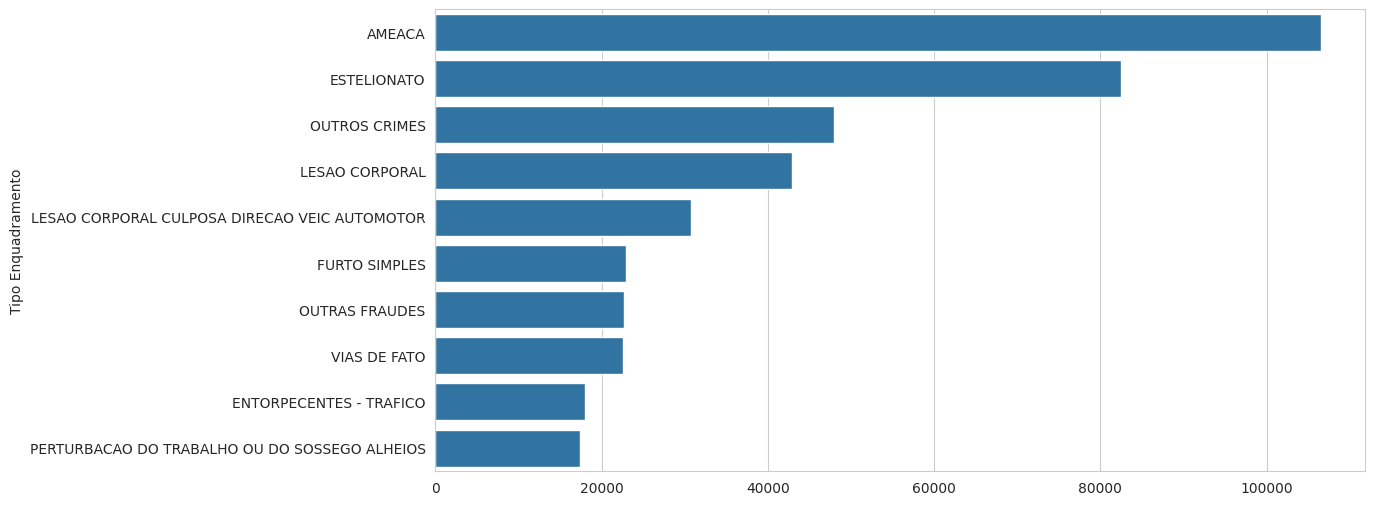

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_crimes.values,
    y=top_crimes.index
)

Ameaça e Estelionato são os crimes mais registrados no estado.

## Quais cidades concentram mais mortes violentas?

In [18]:
mortes = [
    'HOMICIDIO DOLOSO',
    'LATROCINIO',
    'ROUBO COM MORTE'
]

df_mortes = df_tratado[
    df_tratado['Tipo Enquadramento'].isin(mortes)
]

top10_mortes = (
    df_mortes
    .groupby('Municipio Fato')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top10_mortes)

Municipio Fato
PORTO ALEGRE       171
ALVORADA            37
PASSO FUNDO         33
SANTA MARIA         31
VIAMAO              30
CAXIAS DO SUL       29
CANOAS              26
BENTO GONCALVES     23
RIO GRANDE          17
GRAVATAI            15
dtype: int64


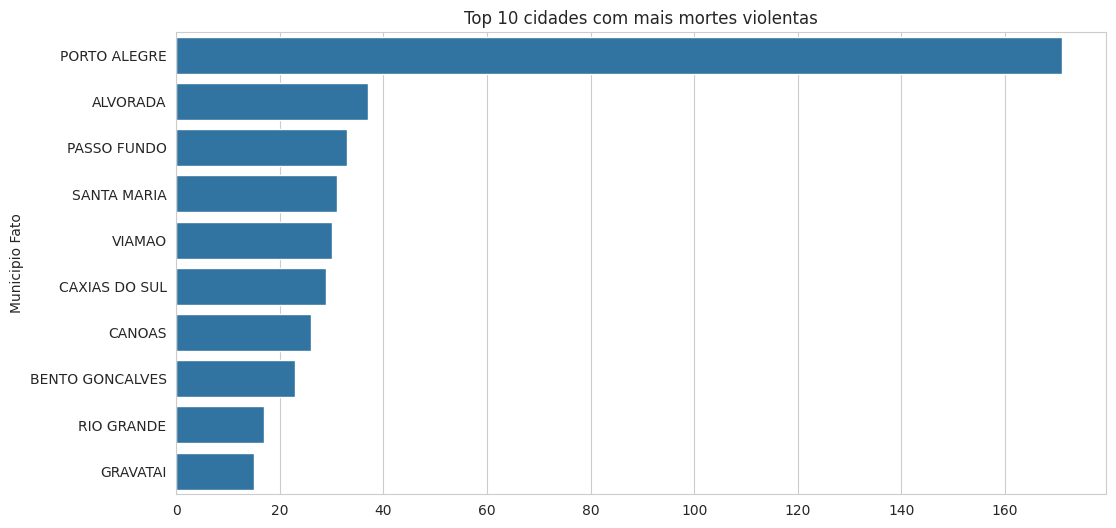

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top10_mortes.values,
    y=top10_mortes.index
)

plt.title('Top 10 cidades com mais mortes violentas')
plt.show()

## Qual os bairro mais perigoso de Porto Alegre


In [20]:
cidades = [
    'PORTO ALEGRE',
]

for cidade in cidades:

    bairro = (
        df_tratado[df_tratado['Municipio Fato'] == cidade]
        ['Bairro']
        .value_counts()
        .head(5)
    )

    print('\n')
    print(cidade)
    print(bairro)



PORTO ALEGRE
Bairro
CENTRO HISTÓRICO    10370
NÃO INFORMADO        7283
PARTENON             5112
RESTINGA             4825
SARANDI              4260
Name: count, dtype: int64


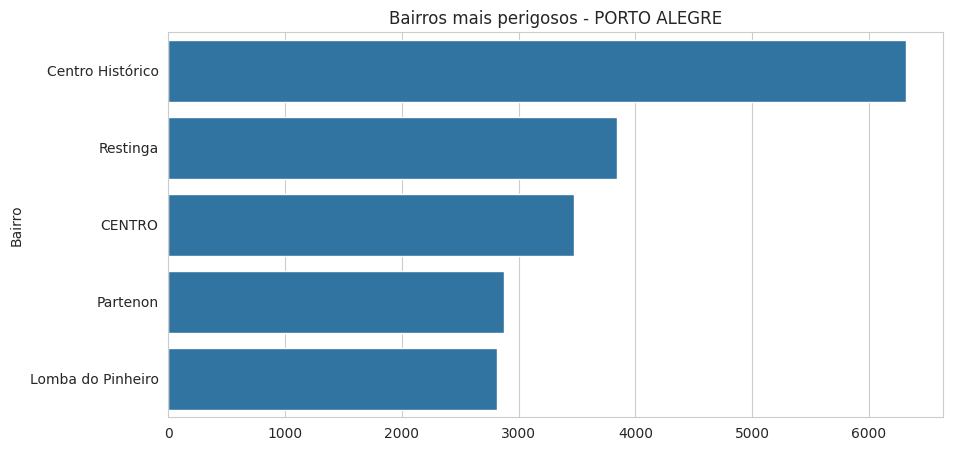

In [21]:
for cidade in cidades:

    bairro = (
        df[df['Municipio Fato'] == cidade]
        ['Bairro']
        .value_counts()
        .head(5)
    )

    plt.figure(figsize=(10,5))

    sns.barplot(
        x=bairro.values,
        y=bairro.index
    )

    plt.title(
        f'Bairros mais perigosos - {cidade}'
    )

    plt.show()

## Quais os 3 bairros com mais roubos e furtos de Porto Alegre?


In [22]:
poa = df_tratado[
    df_tratado['Municipio Fato'] == 'PORTO ALEGRE'
]

roubo_furto = poa[
    poa['Tipo Enquadramento']
    .str.contains(
        'ROUBO|FURTO',
        na=False
    )
]

top3 = (
    roubo_furto['Bairro']
    .value_counts()
    .head(10)
)

print(top3)

Bairro
CENTRO HISTÓRICO    4999
NÃO INFORMADO       2097
PARTENON            1426
FLORESTA            1274
SARANDI             1228
PASSO D'AREIA       1134
PETRÓPOLIS          1085
PRAIA DE BELAS      1078
CIDADE BAIXA        1071
SANTANA             1014
Name: count, dtype: int64


In [23]:
media_diaria = top3 / 365

print(media_diaria.round(2))

Bairro
CENTRO HISTÓRICO    13.70
NÃO INFORMADO        5.75
PARTENON             3.91
FLORESTA             3.49
SARANDI              3.36
PASSO D'AREIA        3.11
PETRÓPOLIS           2.97
PRAIA DE BELAS       2.95
CIDADE BAIXA         2.93
SANTANA              2.78
Name: count, dtype: float64


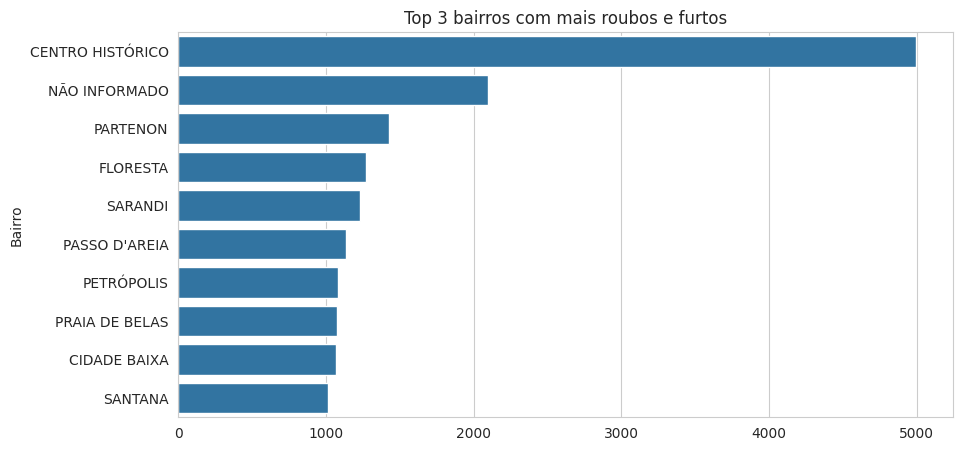

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top3.values,
    y=top3.index
)

plt.title(
    'Top 3 bairros com mais roubos e furtos'
)

plt.show()

## Existe hora marcada para cair em golpe?

In [25]:
estelionato = df_tratado[
    df_tratado['Tipo Enquadramento'].str.contains(
        'ESTELIONATO', case=False, na=False)]

estelionato['Periodo_Dia'].value_counts(normalize=True) * 100

,proportion
Periodo_Dia,
Tarde,48.918692
Manhã,34.473937
Noite,14.783539
Madrugada,1.823833


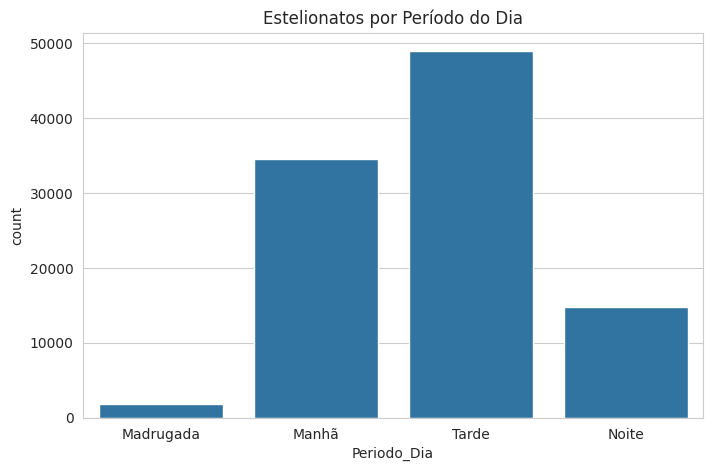

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=estelionato,
    x='Periodo_Dia',
    order=['Madrugada','Manhã','Tarde','Noite'])

plt.title('Estelionatos por Período do Dia')
plt.show()

## Interpretação

Os estelionatos concentram-se principalmente durante a manhã e a tarde, representando mais de 83% dos registros. O resultado sugere forte relação entre golpes e atividades comerciais e financeiras realizadas durante o horário comercial.

## Quem é o alvo principal dos golpistas?

In [27]:
estelionato['Idade Vítima'].describe()

,Idade Vítima
count,100064.000000
mean,47.335385
std,15.903734
min,0.000000
25%,35.000000
50%,46.000000
75%,60.000000
max,125.000000


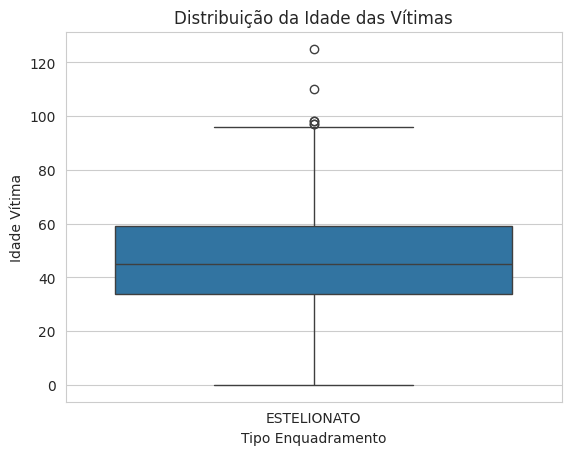

In [28]:
# Gráfico
sns.boxplot(
    data=df_tratado[
        df_tratado['Tipo Enquadramento'].isin(['ESTELIONATO'])],
    x='Tipo Enquadramento',
    y='Idade Vítima')

plt.title('Distribuição da Idade das Vítimas')
plt.show()

## **Interpretação**

A vítima típica de estelionato possui idade mediana de 46 anos, indicando que os golpes atingem principalmente adultos economicamente ativos e não apenas idosos.

# **Como o comportamento do crime muda quando o sol se põe?**

In [29]:
crimes_periodo_pct = pd.crosstab(
    df_tratado['Periodo_Dia'],
    df_tratado['Tipo Enquadramento'],
    normalize='columns') * 100

crimes_periodo_pct[
    ['ESTELIONATO',
     'AMEACA',
     'LESAO CORPORAL', 'ROUBO DE VEICULO']].round(2)

Tipo Enquadramento,ESTELIONATO,AMEACA,LESAO CORPORAL,ROUBO DE VEICULO
Periodo_Dia,,,,
Madrugada,1.80,6.64,16.98,14.23
Manhã,34.34,25.61,18.42,11.96
Noite,14.93,31.58,36.48,54.17
Tarde,48.92,36.17,28.12,19.64


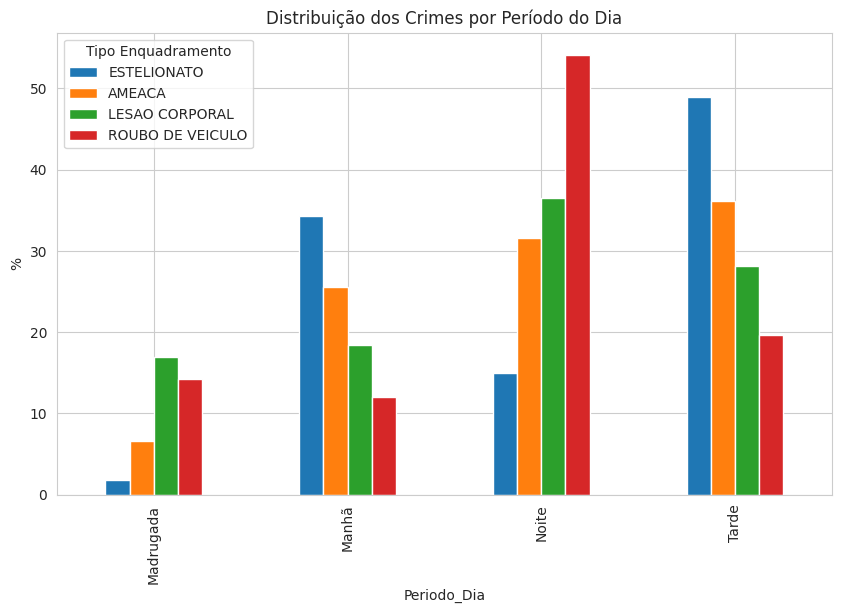

In [30]:
comparacao = crimes_periodo_pct[
    ['ESTELIONATO','AMEACA','LESAO CORPORAL','ROUBO DE VEICULO']]

comparacao.plot(kind='bar',figsize=(10,6))

plt.title('Distribuição dos Crimes por Período do Dia')

plt.ylabel('%')
plt.show()

## **Interpretação**

Enquanto os estelionatos ocorrem majoritariamente durante o dia, os casos de lesão corporal aumentam significativamente à noite e na madrugada. A violência física apresenta comportamento oposto aos crimes financeiros.

# **Roubo de veículos e celulares: quando acontecem?**

In [31]:
roubos = df_tratado[
    df_tratado['Tipo Enquadramento'].str.contains(
        'ROUBO',
        na=False
    )
]

roubos_celular = roubos[
    roubos['Tipo Enquadramento'].str.contains(
        'CELULAR',
        na=False
    )
]

roubos_veiculo = roubos[
    roubos['Tipo Enquadramento'].str.contains(
        'VEICULO',
        na=False
    )
]

In [32]:
pd.crosstab(
    roubos_celular['Periodo_Dia'],
    columns='Celular',
    normalize='columns'
)*100

col_0,Celular
Periodo_Dia,
Madrugada,15.780731
Manhã,20.805648
Noite,39.908638
Tarde,23.504983


In [33]:
pd.crosstab(
    roubos_veiculo['Periodo_Dia'],
    columns='Veículo',
    normalize='columns'
)*100

col_0,Veículo
Periodo_Dia,
Madrugada,14.916201
Manhã,12.178771
Noite,53.351955
Tarde,19.553073


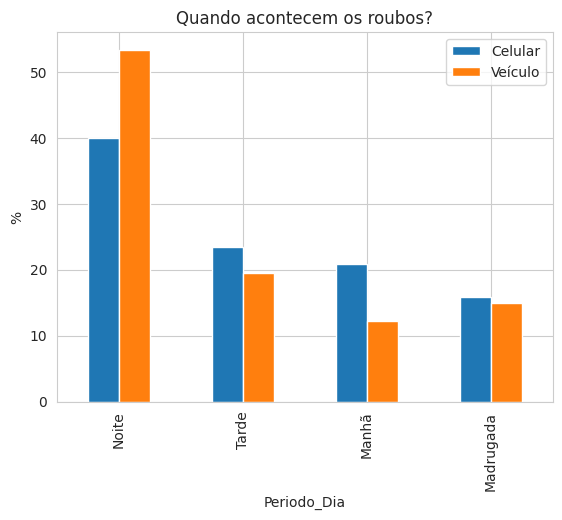

In [34]:
comparacao = pd.concat([
    roubos_celular['Periodo_Dia'].value_counts(normalize=True)*100,
    roubos_veiculo['Periodo_Dia'].value_counts(normalize=True)*100
], axis=1)

comparacao.columns = ['Celular','Veículo']

comparacao.plot(kind='bar')

plt.title('Quando acontecem os roubos?')
plt.ylabel('%')
plt.show()

# Existe diferença de gênero nos tipos de violência registrados?

In [35]:
genero_crimes = pd.crosstab(
    df_tratado['Tipo Enquadramento'],df_tratado['Sexo Vítima'],normalize='index') * 100

genero_crimes.loc[['AMEACA','LESAO CORPORAL','ESTELIONATO', 'ROUBO DE VEICULO']]

Sexo Vítima,Feminino,Masculino,Não Informado
Tipo Enquadramento,,,
AMEACA,56.628836,41.263717,2.107447
LESAO CORPORAL,56.954971,41.083879,1.961150
ESTELIONATO,48.171715,48.131719,3.696566
ROUBO DE VEICULO,22.559524,73.809524,3.630952


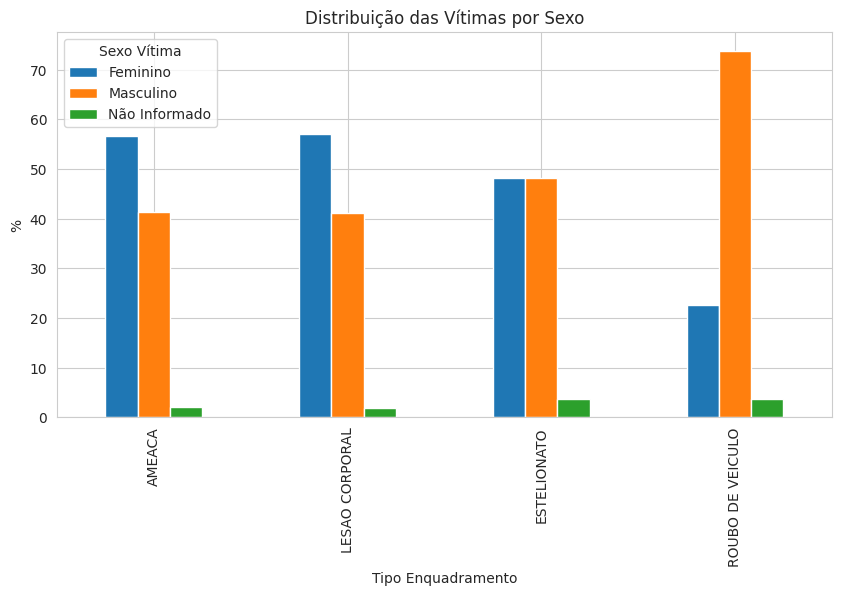

In [36]:
# Gráfico
genero_crimes.loc[
    ['AMEACA','LESAO CORPORAL','ESTELIONATO', 'ROUBO DE VEICULO']
    ].plot(kind='bar',figsize=(10,5))

plt.title('Distribuição das Vítimas por Sexo')

plt.ylabel('%')
plt.show()

## Interpretação

Mulheres representam a maioria das vítimas em ocorrências de ameaça e lesão corporal. Já os casos de estelionato apresentam distribuição praticamente equilibrada entre homens e mulheres.

# O crime muda de endereço ao longo do dia?

In [37]:
locais_periodo = pd.crosstab(
    df_tratado['Periodo_Dia'],
    df_tratado['Local Fato'],
    normalize='index'
) * 100

locais_periodo[
    ['RESIDENCIA',
     'VIA PUBLICA',
     'ESTABELECIMENTO COMERCIAL',
     'OUTROS']
].round(2)

Local Fato,RESIDENCIA,VIA PUBLICA,ESTABELECIMENTO COMERCIAL,OUTROS
Periodo_Dia,,,,
Madrugada,28.85,26.96,5.42,35.65
Manhã,28.40,15.50,5.57,46.95
Noite,30.74,25.83,4.16,37.21
Tarde,26.84,17.78,5.39,47.12


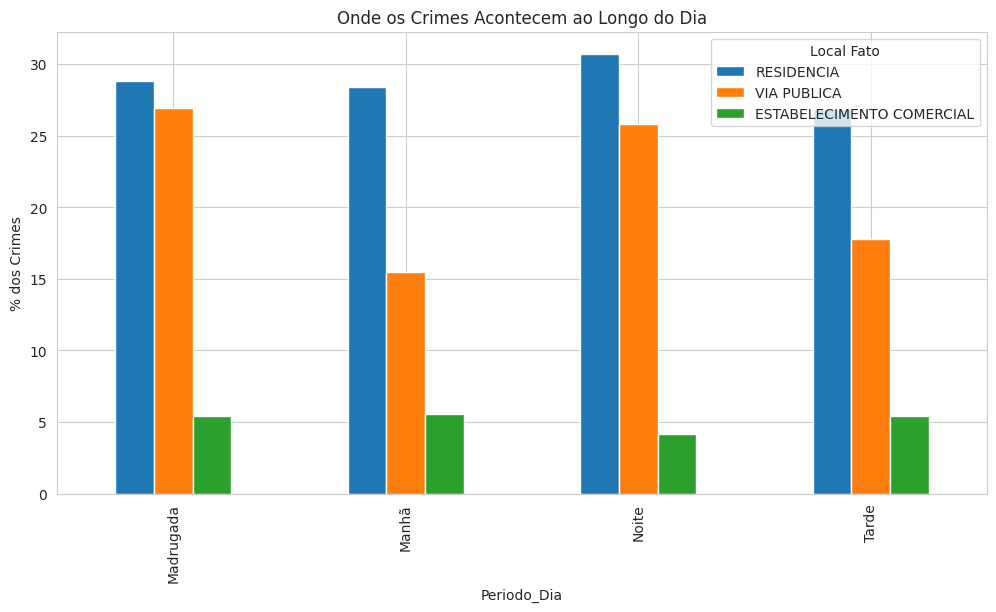

In [38]:
locais_periodo[
    ['RESIDENCIA',
     'VIA PUBLICA',
     'ESTABELECIMENTO COMERCIAL']
].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Onde os Crimes Acontecem ao Longo do Dia')
plt.ylabel('% dos Crimes')
plt.show()

## Interpretação
O crime muda claramente de endereço ao longo do dia. Durante o expediente predominam ocorrências em vias públicas e estabelecimentos comerciais. À noite, os registros migram para residências, indicando aumento de conflitos interpessoais e violência doméstica

# Qual patrimônio é o alvo favorito dos criminosos?
- Roubo de celular
- Roubo de veículo
- Furto de celular
- Furto de veículo

In [39]:
#Verificar os tipos que envolvem celular e veículo
alvos = df_tratado[
    df_tratado['Tipo Enquadramento'].str.contains(
        'CELULAR|VEICULO',
        na=False)]
alvos['Tipo Enquadramento'].value_counts().head(20)

,count
Tipo Enquadramento,
FURTO DE CELULAR,11904
FURTO EM VEICULO,7185
FURTO DE VEICULO,6303
ROUBO DE CELULAR,2408
ADULTERACAO DE SINAL IDENTIFICADOR DE VEICULO AUTOMOTOR,2148
ROUBO DE VEICULO,1680
FURTO EM VEICULO - ESTEPE,1135
RECEPTACAO DE VEICULO,632
VIOLAR A SUSPENSAO OU PROIBICAO DE DIRIGIR VEICULO ART.307,517


In [40]:
celular = df_tratado[
    df_tratado['Tipo Enquadramento'].isin(['FURTO DE CELULAR','ROUBO DE CELULAR'])]

veiculo = df_tratado[
    df_tratado['Tipo Enquadramento'].isin(['FURTO DE VEICULO','FURTO EM VEICULO','ROUBO DE VEICULO','ROUBO DE VEICULO COM LESOES','ROUBO DE VEICULO COM MORTE'])]

comparacao = pd.DataFrame({
    'Celular': [len(celular)],
    'Veiculo': [len(veiculo)]
})

comparacao

,Celular,Veiculo
0,14312,15278


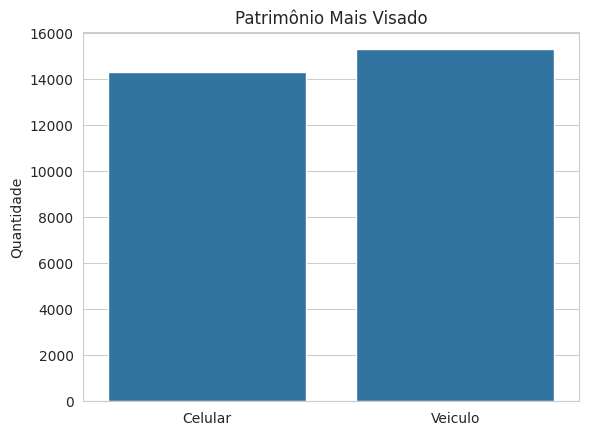

In [41]:
sns.barplot(
    data=comparacao.melt(),
    x='variable',
    y='value')

plt.title('Patrimônio Mais Visado')
plt.xlabel('')
plt.ylabel('Quantidade')
plt.show()

Foram registrados 11.904 furtos de celular e apenas 2.408 roubos de celular. Isso indica que o criminoso prefere agir sem contato direto com a vítima. Nos veículos ocorre comportamento semelhante: os furtos (13.488 ocorrências) superam amplamente os roubos (1.790 ocorrências).

# **Conclusão**

A análise dos mais de **763 mil registros de ocorrências do Rio Grande do Sul** permitiu identificar padrões importantes sobre a criminalidade no estado.

Os resultados mostraram que crimes como **Estelionato** acontecem principalmente durante o **horário comercial**, enquanto crimes de **Lesão Corporal aumentam durante a noite e madrugada**. Também foi possível observar que o local das ocorrências muda ao longo do dia, saindo das vias públicas e estabelecimentos comerciais para as residências.

Outro ponto interessante foi o perfil das vítimas. No **estelionato**, a idade mediana encontrada foi de **46 anos**, mostrando que os golpes atingem principalmente adultos economicamente ativos. Já em crimes como **ameaça e lesão corporal, houve maior participação de vítimas do sexo feminino**.

Por fim, a análise dos **crimes patrimoniais** indicou que **celulares** são um dos principais alvos dos criminosos, e que os furtos acontecem com muito mais frequência do que os roubos.

Este trabalho demonstrou como a análise de dados pode transformar registros brutos em informações úteis para entender melhor a realidade da segurança pública e auxiliar na tomada de decisões.

In [42]:
try:
    from google.colab import drive
    output_path = '/content/drive/MyDrive/COLAB DATASET/df_tratado0110.csv'
except ImportError:
    output_path = 'df_tratado.csv'

df_tratado.to_csv(output_path, index=False)
print(f"DataFrame exportado com sucesso para: {output_path}")

DataFrame exportado com sucesso para: /content/drive/MyDrive/COLAB DATASET/df_tratado0110.csv


In [43]:
df['Idade Vítima'].max()

125.0